## 1. გარემოს მომზადება - Kaggle & მონაცემების ჩამოტვირთვა

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler

import mlflow

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"გამოყენებული device: {device}")

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (12, 5)

გამოყენებული device: cpu


In [2]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!pip install kaggle
!kaggle competitions list

ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

In [3]:
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting
!unzip -o walmart-recruiting-store-sales-forecasting.zip -d data/

100% 2.70M/2.70M [00:00<00:00, 134MB/s]

Archive:  walmart-recruiting-store-sales-forecasting.zip
  inflating: data/features.csv.zip   
  inflating: data/sampleSubmission.csv.zip  
  inflating: data/stores.csv         
  inflating: data/test.csv.zip       
  inflating: data/train.csv.zip      


In [4]:
!pip install --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.5/247.5 kB 9.4 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [5]:
!kaggle competitions list

ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

In [6]:
!kaggle datasets download -d aslanahmedov/walmart-sales-forecast


Dataset URL: https://www.kaggle.com/datasets/aslanahmedov/walmart-sales-forecast
License(s): copyright-authors
100% 3.36M/3.36M [00:00<00:00, 200MB/s]



In [7]:
!unzip -o walmart-sales-forecast.zip -d data/


Archive:  walmart-sales-forecast.zip
  inflating: data/features.csv       
  inflating: data/stores.csv         
  inflating: data/test.csv           
  inflating: data/train.csv          


In [8]:
!pip install -q dagshub mlflow==2.22.0 lightgbm shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954

In [51]:
import dagshub
import mlflow

dagshub.init(
    repo_owner='aleko-mamukashvili',
    repo_name='Store-Sales-Forecasting',
    mlflow=True
)

EXPERIMENT_NAME = "N-BEATS_Training"
mlflow.set_experiment(EXPERIMENT_NAME)

Initialized MLflow to track repo "aleko-mamukashvili/Store-Sales-Forecasting"

Repository aleko-mamukashvili/Store-Sales-Forecasting initialized!

2026/07/12 08:32:47 INFO mlflow.tracking.fluent: Experiment with name 'N-BEATS_Training' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/8f976e6e4078486da50b4ad72abb84cf', creation_time=1783845167495, experiment_id='5', last_update_time=1783845167495, lifecycle_stage='active', name='N-BEATS_Training', tags={}>

In [12]:

import pandas as pd
import numpy as np
DATA_PATH = "data"

train_raw = pd.read_csv(f"{DATA_PATH}/train.csv")
train_raw['Date'] = pd.to_datetime(train_raw['Date'])

agg = train_raw.groupby('Date').agg(
    y=('Weekly_Sales', 'sum'),
    IsHoliday=('IsHoliday', 'max'),
).reset_index()

print(agg.shape)
agg.head()

(143, 3)


,Date,y,IsHoliday
0,2010-02-05,49750740.50,False
1,2010-02-12,48336677.63,True
2,2010-02-19,48276993.78,False
3,2010-02-26,43968571.13,False
4,2010-03-05,46871470.30,False


# EDA გადაწყვეტილებები

In [13]:
VAL_START = pd.Timestamp('2011-11-01')
VAL_END = pd.Timestamp('2012-02-15')

train_series = agg[agg['Date'] < VAL_START].reset_index(drop=True)
val_series = agg[(agg['Date'] >= VAL_START) & (agg['Date'] <= VAL_END)].reset_index(drop=True)

print(f"Train სერია: {len(train_series)} კვირა ({train_series['Date'].min().date()} -> {train_series['Date'].max().date()})")
print(f"Val სერია:   {len(val_series)} კვირა ({val_series['Date'].min().date()} -> {val_series['Date'].max().date()})")

Train სერია: 91 კვირა (2010-02-05 -> 2011-10-28)
Val სერია:   15 კვირა (2011-11-04 -> 2012-02-10)


In [18]:
print(f"სულ ხელმისაწვდომი (labeled) სერია: {len(agg)} კვირა "
      f"({agg['Date'].min().date()} -> {agg['Date'].max().date()})")

სულ ხელმისაწვდომი (labeled) სერია: 143 კვირა (2010-02-05 -> 2012-10-26)


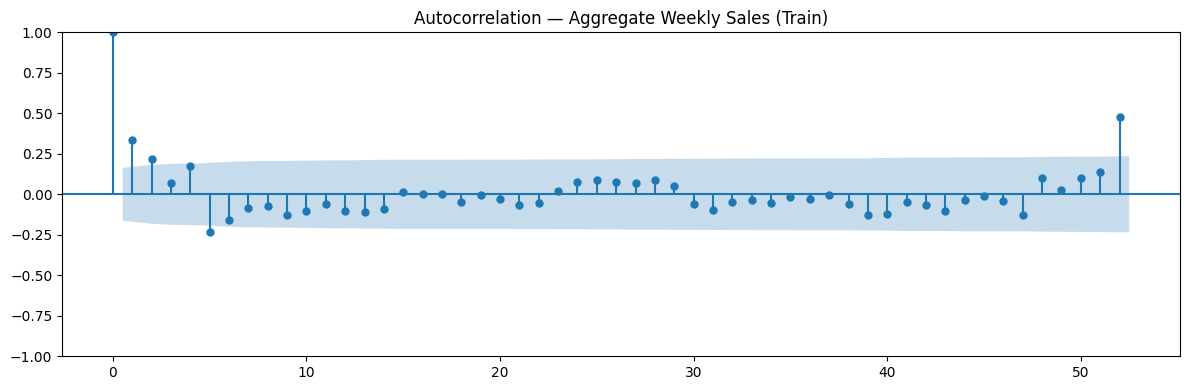

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(agg['y'], lags=52, ax=ax)
ax.set_title('Autocorrelation — Aggregate Weekly Sales (Train)')
plt.tight_layout()
plt.show()

In [20]:
print("y დიაპაზონი:", agg['y'].min(), "->", agg['y'].max())
print("Train y საშუალო/std:", train_series['y'].mean(), "/", train_series['y'].std())

y დიაპაზონი: 39599852.99 -> 80931415.6
Train y საშუალო/std: 46580721.65285715 / 5152370.589991516


# Train/Validation splitting

In [23]:
VAL_START = pd.Timestamp('2011-11-01')
VAL_END = pd.Timestamp('2012-02-15')

train_series = agg[agg['Date'] < VAL_START].reset_index(drop=True)
val_series = agg[(agg['Date'] >= VAL_START) & (agg['Date'] <= VAL_END)].reset_index(drop=True)

print(f"Train სერია: {len(train_series)} კვირა ({train_series['Date'].min().date()} -> {train_series['Date'].max().date()})")
print(f"Val სერია:   {len(val_series)} კვირა ({val_series['Date'].min().date()} -> {val_series['Date'].max().date()})")

BACKCAST_LENGTH_CHECK = 52
FORECAST_LENGTH_CHECK = 15
n_windows_available = len(train_series) - BACKCAST_LENGTH_CHECK - FORECAST_LENGTH_CHECK + 1
print(f"{len(train_series)} - {BACKCAST_LENGTH_CHECK} - {FORECAST_LENGTH_CHECK} + 1 = "
      f"{n_windows_available} training window (stride=1)")

Train სერია: 91 კვირა (2010-02-05 -> 2011-10-28)
Val სერია:   15 კვირა (2011-11-04 -> 2012-02-10)
91 - 52 - 15 + 1 = 25 training window (stride=1)


# Feature Engineering

In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_series[['y']]).flatten()

full_series_scaled = scaler.transform(agg[['y']]).flatten()

print("Train scaled დიაპაზონი:", train_scaled.min(), "->", train_scaled.max())

Train scaled დიაპაზონი: 0.0 -> 1.0


## Sliding window dataset

In [28]:
import torch
from torch.utils.data import Dataset

BACKCAST_LENGTH = 52
FORECAST_LENGTH = 15  # ზუსტად ემთხვევა ჩვენს holiday-aware validation window-ს

class SlidingWindowDataset(Dataset):
    """
    Sliding-window-ით აგენერირებს (backcast, forecast) წყვილებს ერთი სერიიდან.
    stride=1 ნიშნავს, რომ სერიის ყოველი შესაძლო წერტილიდან ვიღებთ ცალკე training example-ს
    """
    def __init__(self, series, backcast_len, forecast_len, stride=1):
        self.series = series
        self.backcast_len = backcast_len
        self.forecast_len = forecast_len
        self.indices = list(range(0, len(series) - backcast_len - forecast_len + 1, stride))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        x = self.series[i : i + self.backcast_len]
        y = self.series[i + self.backcast_len : i + self.backcast_len + self.forecast_len]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


full_train_dataset = SlidingWindowDataset(train_scaled, BACKCAST_LENGTH, FORECAST_LENGTH)
print(f"სულ training window-ები: {len(full_train_dataset)}")

# ბოლო 5 window-ს ვტოვებთ internal validation-ად
N_INTERNAL_VAL = 5
internal_train_indices = full_train_dataset.indices[:-N_INTERNAL_VAL]
internal_val_indices = full_train_dataset.indices[-N_INTERNAL_VAL:]

print(f"Internal train windows: {len(internal_train_indices)}, internal val windows: {len(internal_val_indices)}")

სულ training window-ები: 25
Internal train windows: 20, internal val windows: 5


In [29]:
class IndexedSubset(Dataset):
    def __init__(self, series, indices, backcast_len, forecast_len):
        self.series = series
        self.indices = indices
        self.backcast_len = backcast_len
        self.forecast_len = forecast_len

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        x = self.series[i : i + self.backcast_len]
        y = self.series[i + self.backcast_len : i + self.backcast_len + self.forecast_len]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


internal_train_ds = IndexedSubset(train_scaled, internal_train_indices, BACKCAST_LENGTH, FORECAST_LENGTH)
internal_val_ds = IndexedSubset(train_scaled, internal_val_indices, BACKCAST_LENGTH, FORECAST_LENGTH)

true_val_backcast = torch.tensor(full_series_scaled[len(train_scaled) - BACKCAST_LENGTH: len(train_scaled)], dtype=torch.float32)
true_val_forecast_scaled = full_series_scaled[len(train_scaled): len(train_scaled) + FORECAST_LENGTH]

print("Internal train/val sizes:", len(internal_train_ds), len(internal_val_ds))

print("True validation backcast/forecast shapes:", true_val_backcast.shape, true_val_forecast_scaled.shape)

Internal train/val sizes: 20 5
True validation backcast/forecast shapes: torch.Size([52]) (15,)


## Nbeats არქიტექტურა

In [32]:
import numpy as np
import torch
import torch.nn as nn

class GenericBasis(nn.Module):
    def __init__(self, backcast_len, forecast_len):
        super().__init__()
        self.backcast_len = backcast_len
        self.forecast_len = forecast_len

    def forward(self, theta):
        backcast = theta[:, :self.backcast_len]
        forecast = theta[:, self.backcast_len:self.backcast_len + self.forecast_len]
        return backcast, forecast


class TrendBasis(nn.Module):
    """პოლინომიალური საფუძველიტრენდის ოდელირებისთვის."""
    def __init__(self, degree, backcast_len, forecast_len):
        super().__init__()
        self.degree = degree
        t_backcast = np.linspace(0, 1, backcast_len)
        t_forecast = np.linspace(0, 1, forecast_len)
        self.register_buffer('T_backcast', torch.tensor(
            np.stack([t_backcast ** i for i in range(degree)]), dtype=torch.float32))
        self.register_buffer('T_forecast', torch.tensor(
            np.stack([t_forecast ** i for i in range(degree)]), dtype=torch.float32))

    def forward(self, theta):
        theta_backcast = theta[:, :self.degree]
        theta_forecast = theta[:, self.degree:2 * self.degree]
        backcast = theta_backcast @ self.T_backcast
        forecast = theta_forecast @ self.T_forecast
        return backcast, forecast


class SeasonalityBasis(nn.Module):
    """Fourier საფუძველი """
    def __init__(self, num_harmonics, backcast_len, forecast_len):
        super().__init__()
        self.num_harmonics = num_harmonics
        t_backcast = np.arange(backcast_len) / 52.0
        t_forecast = (backcast_len + np.arange(forecast_len)) / 52.0

        def fourier_matrix(t):
            terms = [np.ones_like(t)]
            for h in range(1, num_harmonics + 1):
                terms.append(np.cos(2 * np.pi * h * t))
                terms.append(np.sin(2 * np.pi * h * t))
            return np.stack(terms)

        self.register_buffer('F_backcast', torch.tensor(fourier_matrix(t_backcast), dtype=torch.float32))
        self.register_buffer('F_forecast', torch.tensor(fourier_matrix(t_forecast), dtype=torch.float32))
        self.n_terms = 2 * num_harmonics + 1

    def forward(self, theta):
        theta_backcast = theta[:, :self.n_terms]
        theta_forecast = theta[:, self.n_terms:2 * self.n_terms]
        backcast = theta_backcast @ self.F_backcast
        forecast = theta_forecast @ self.F_forecast
        return backcast, forecast

# Doubly residual არქტიექტურა

In [39]:
class NBeatsBlock(nn.Module):
    """
    Fully-connected stack -> theta -> basis function -> (backcast, forecast).
    Doubly residual პრინციპი თითოეული block აგენერირებს ნაწილობრივ backcast/forecast-ს,
    """
    def __init__(self, input_dim, hidden_dim, n_fc_layers, basis, theta_dim):
        super().__init__()
        layers = []
        d = input_dim
        for _ in range(n_fc_layers):
            layers += [nn.Linear(d, hidden_dim), nn.ReLU()]
            d = hidden_dim
        self.fc_stack = nn.Sequential(*layers)
        self.theta_layer = nn.Linear(hidden_dim, theta_dim)
        self.basis = basis

    def forward(self, x):
        h = self.fc_stack(x)
        theta = self.theta_layer(h)
        backcast, forecast = self.basis(theta)
        return backcast, forecast


class NBeatsStack(nn.Module):
    def __init__(self, block_type, n_blocks, backcast_len, forecast_len, hidden_dim, n_fc_layers,
                 degree=3, num_harmonics=4):
        super().__init__()
        blocks = []
        for _ in range(n_blocks):
            if block_type == 'generic':
                basis = GenericBasis(backcast_len, forecast_len)
                theta_dim = backcast_len + forecast_len
            elif block_type == 'trend':
                basis = TrendBasis(degree, backcast_len, forecast_len)
                theta_dim = 2 * degree
            elif block_type == 'seasonality':
                basis = SeasonalityBasis(num_harmonics, backcast_len, forecast_len)
                theta_dim = 2 * (2 * num_harmonics + 1)
            else:
                raise ValueError(block_type)
            blocks.append(NBeatsBlock(backcast_len, hidden_dim, n_fc_layers, basis, theta_dim))
        self.blocks = nn.ModuleList(blocks)
        self.forecast_len = forecast_len

    def forward(self, x):
        residual = x
        stack_forecast = torch.zeros(x.shape[0], self.forecast_len, device=x.device)
        for block in self.blocks:
            backcast, forecast = block(residual)
            residual = residual - backcast
            stack_forecast = stack_forecast + forecast
        return residual, stack_forecast


class NBeatsNet(nn.Module):
    """სტეკების ჯაჭვი თითოეული სტეკი წინას residual-ზე მუშაობს, forecast-ები ჯამდება."""
    def __init__(self, stack_types, backcast_len, forecast_len, hidden_dim=64, n_fc_layers=3,
                 n_blocks_per_stack=2, degree=3, num_harmonics=4):
        super().__init__()
        self.stacks = nn.ModuleList([
            NBeatsStack(st, n_blocks_per_stack, backcast_len, forecast_len, hidden_dim, n_fc_layers,
                        degree=degree, num_harmonics=num_harmonics)
            for st in stack_types
        ])
        self.forecast_len = forecast_len

    def forward(self, x):
        residual = x
        total_forecast = torch.zeros(x.shape[0], self.forecast_len, device=x.device)
        for stack in self.stacks:
            residual, stack_forecast = stack(residual)
            total_forecast = total_forecast + stack_forecast
        return total_forecast

# metrikebi da MLflow logging helperebi

In [34]:
def week_index_to_weight(start_idx, length, holiday_flags):
    """holiday კვირებს 5x წონას ანიჭებს იგივე პრინციპი, რაც LightGBM/Prophet-ში."""
    return np.where(holiday_flags[start_idx:start_idx + length], 5.0, 1.0)


class WeightedMAELoss(nn.Module):
    """ტრენინგის loss წონიანი L1, რომ ქსელმა holidayკვირებს მეტი ყურადღება მიაქციოს."""
    def forward(self, pred, target, weights):
        return torch.mean(weights * torch.abs(pred - target))


def wmae_original_scale(y_true_scaled, y_pred_scaled, scaler, is_holiday):

    y_true = scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    weights = np.where(np.asarray(is_holiday).astype(bool), 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)


def wmae(y_true, y_pred, is_holiday):
    """მარტივი row-level WMAE ორიგინალ სკალაზე, Store/Dept-დონის შედარებისთვის."""
    w = np.where(np.asarray(is_holiday).astype(bool), 5, 1)
    return np.sum(w * np.abs(np.asarray(y_true) - np.asarray(y_pred))) / np.sum(w)

In [35]:
def train_nbeats(model, train_ds, val_ds, epochs=100, lr=1e-3, batch_size=8, verbose=False):
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss()

    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        train_losses.append(epoch_loss / len(train_ds))

        model.eval()
        with torch.no_grad():
            val_loss = 0.0
            for xb, yb in DataLoader(val_ds, batch_size=len(val_ds)):
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                val_loss += criterion(pred, yb).item() * len(xb)
            val_losses.append(val_loss / max(len(val_ds), 1))

        if verbose and (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs} — train_loss={train_losses[-1]:.4f}, internal_val_loss={val_losses[-1]:.4f}")

    return train_losses, val_losses

In [36]:
def evaluate_on_true_val(model):
    model.eval()
    with torch.no_grad():
        x = true_val_backcast.unsqueeze(0).to(device)
        pred_scaled = model(x).cpu().numpy().flatten()
    val_holiday_flags = val_series['IsHoliday'].values
    wmae_val = wmae_original_scale(true_val_forecast_scaled, pred_scaled, scaler, val_holiday_flags)
    return wmae_val, pred_scaled


def plot_true_val_forecast(pred_scaled, title):
    pred_original = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    fig, ax = plt.subplots()
    ax.plot(train_series['Date'].iloc[-30:], train_series['y'].iloc[-30:], color='#4C72B0', label='Actual (Train, ბოლო 30კვ)')
    ax.plot(val_series['Date'], val_series['y'], color='#C44E52', label='Actual (Val)')
    ax.plot(val_series['Date'], pred_original, color='#C44E52', linestyle='--', label='Predicted (Val)')
    ax.axvline(train_series['Date'].iloc[-1], color='gray', linestyle=':', label='Train/Val Split')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [37]:
def log_run(run_name, params, metrics, model=None, registered_name=None):
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)
        if model is not None:
            mlflow.pytorch.log_model(
                model, "model",
                registered_model_name=registered_name
            )
        print(run_name, "->", metrics)

# Experiments and Logs

## Run1 BaseLine

In [44]:
torch.manual_seed(42)
model1 = NBeatsNet(stack_types=['generic'], backcast_len=BACKCAST_LENGTH, forecast_len=FORECAST_LENGTH,
                    hidden_dim=64, n_fc_layers=3, n_blocks_per_stack=2).to(device)

tr_losses1, val_losses1 = train_nbeats(model1, internal_train_ds, internal_val_ds, epochs=100, lr=1e-3, batch_size=8)
wmae_val1, pred1 = evaluate_on_true_val(model1)
print(f"Run 1  WMAE_val (true holiday window): {wmae_val1:.1f}")

Run 1 — WMAE_val (true holiday window): 8078331.4


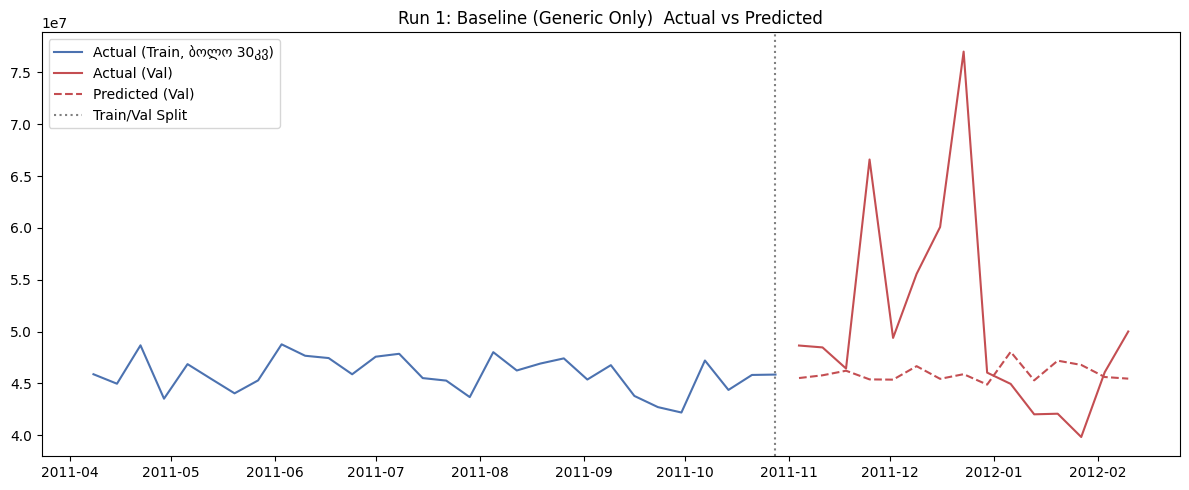

In [45]:
plot_true_val_forecast(pred1, 'Run 1: Baseline (Generic Only)  Actual vs Predicted')

In [52]:
log_run(
    "NBEATS_Baseline_Generic",
    params={'stack_types': 'generic', 'hidden_dim': 64, 'n_fc_layers': 3, 'n_blocks_per_stack': 2, 'epochs': 100},
    metrics={'wmae_val': wmae_val1},
    model=model1,
)

2026/07/12 08:32:55 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 08:33:03 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 08:33:03 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


NBEATS_Baseline_Generic -> {'wmae_val': np.float64(8078331.354814812)}
🏃 View run NBEATS_Baseline_Generic at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/5/runs/4965ee9bb90d4751a4712b30d029a0e6
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/5


## Run2 Trend Stack

In [48]:
torch.manual_seed(42)
model2 = NBeatsNet(stack_types=['trend', 'generic'], backcast_len=BACKCAST_LENGTH, forecast_len=FORECAST_LENGTH,
                    hidden_dim=64, n_fc_layers=3, n_blocks_per_stack=2, degree=3).to(device)

tr_losses2, val_losses2 = train_nbeats(model2, internal_train_ds, internal_val_ds, epochs=100, lr=1e-3, batch_size=8)
wmae_val2, pred2 = evaluate_on_true_val(model2)
print(f"Run 2  WMAE_val: {wmae_val2:.1f}")

Run 2  WMAE_val: 7921389.2


In [53]:
log_run(
    "NBEATS_PlusTrend",
    params={'stack_types': 'trend+generic', 'hidden_dim': 64, 'n_fc_layers': 3, 'n_blocks_per_stack': 2, 'epochs': 100},
    metrics={'wmae_val': wmae_val2},
    model=model2,
)

2026/07/12 08:33:06 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 08:33:12 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 08:33:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


NBEATS_PlusTrend -> {'wmae_val': np.float64(7921389.19185185)}
🏃 View run NBEATS_PlusTrend at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/5/runs/2af0f62c2f3a41fba6c87fb359c82ae7
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/5


## Run3 Sesaonality check

In [54]:
torch.manual_seed(42)
model3 = NBeatsNet(stack_types=['trend', 'seasonality', 'generic'], backcast_len=BACKCAST_LENGTH,
                    forecast_len=FORECAST_LENGTH, hidden_dim=64, n_fc_layers=3, n_blocks_per_stack=2,
                    degree=3, num_harmonics=4).to(device)

tr_losses3, val_losses3 = train_nbeats(model3, internal_train_ds, internal_val_ds, epochs=100, lr=1e-3, batch_size=8)
wmae_val3, pred3 = evaluate_on_true_val(model3)
print(f"Run 3 — WMAE_val: {wmae_val3:.1f}")

Run 3 — WMAE_val: 7888976.5


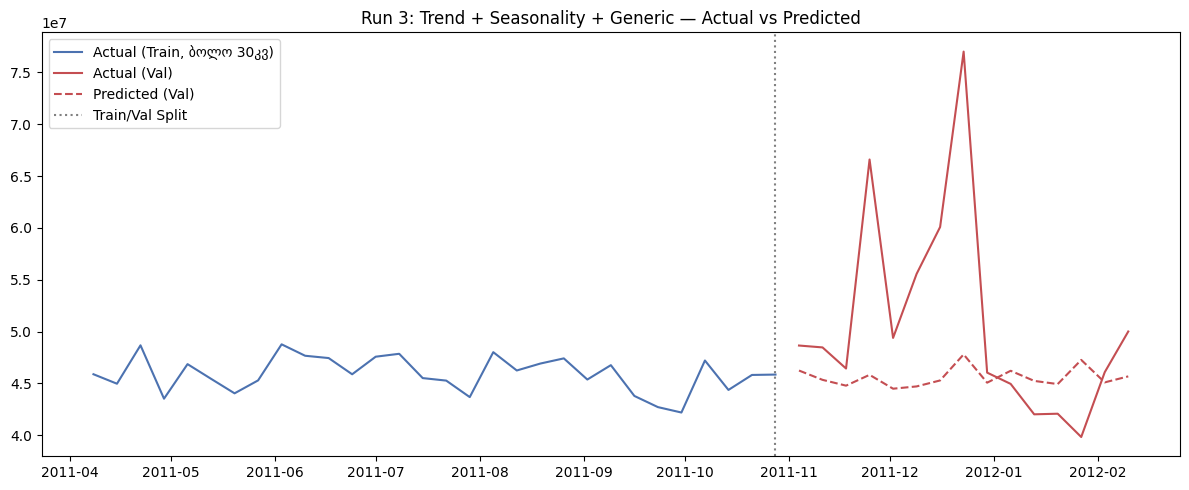

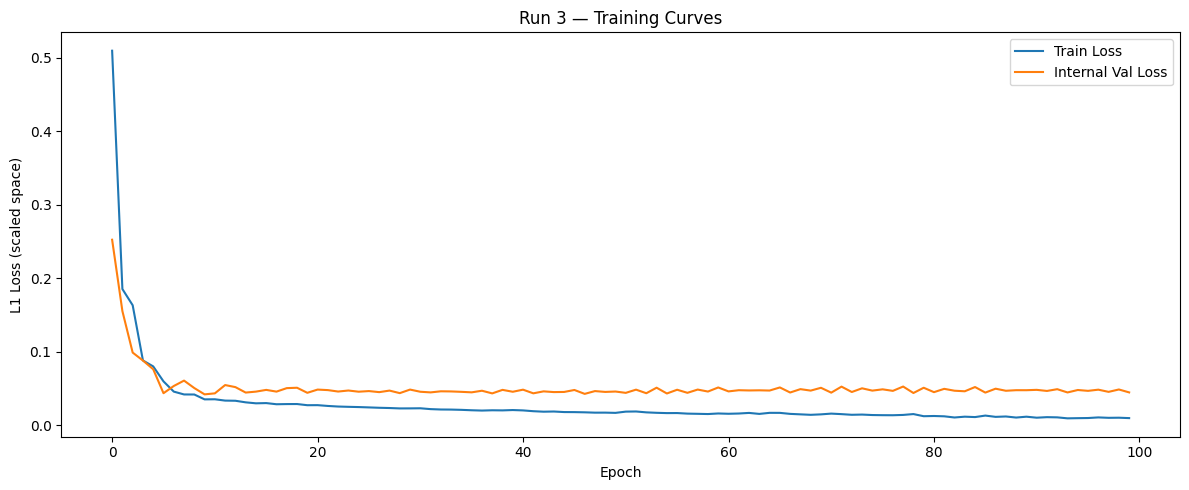

In [55]:
plot_true_val_forecast(pred3, 'Run 3: Trend + Seasonality + Generic — Actual vs Predicted')

fig, ax = plt.subplots()
ax.plot(tr_losses3, label='Train Loss')
ax.plot(val_losses3, label='Internal Val Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('L1 Loss (scaled space)')
ax.set_title('Run 3 — Training Curves')
ax.legend()
plt.tight_layout()
plt.show()

In [56]:
log_run(
    "NBEATS_PlusSeasonality",
    params={'stack_types': 'trend+seasonality+generic', 'hidden_dim': 64, 'n_fc_layers': 3,
            'n_blocks_per_stack': 2, 'degree': 3, 'num_harmonics': 4, 'epochs': 100},
    metrics={'wmae_val': wmae_val3},
    model=model3,
)

2026/07/12 08:34:18 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 08:34:28 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 08:34:28 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


NBEATS_PlusSeasonality -> {'wmae_val': np.float64(7888976.539999997)}
🏃 View run NBEATS_PlusSeasonality at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/5/runs/36c091aa2bbd4a1cb0e1eda2881de2d1
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/5


## Run4 Backcast Length (26kvira 52is magivrad)

In [57]:
BACKCAST_SHORT = 26

train_scaled_short_ds = SlidingWindowDataset(train_scaled, BACKCAST_SHORT, FORECAST_LENGTH)
short_internal_train = IndexedSubset(train_scaled, train_scaled_short_ds.indices[:-N_INTERNAL_VAL], BACKCAST_SHORT, FORECAST_LENGTH)
short_internal_val = IndexedSubset(train_scaled, train_scaled_short_ds.indices[-N_INTERNAL_VAL:], BACKCAST_SHORT, FORECAST_LENGTH)
short_true_val_backcast = torch.tensor(full_series_scaled[len(train_scaled) - BACKCAST_SHORT: len(train_scaled)], dtype=torch.float32)

torch.manual_seed(42)
model4 = NBeatsNet(stack_types=['trend', 'seasonality', 'generic'], backcast_len=BACKCAST_SHORT,
                    forecast_len=FORECAST_LENGTH, hidden_dim=64, n_fc_layers=3, n_blocks_per_stack=2,
                    degree=3, num_harmonics=4).to(device)

tr_losses4, val_losses4 = train_nbeats(model4, short_internal_train, short_internal_val, epochs=100, lr=1e-3, batch_size=8)

model4.eval()
with torch.no_grad():
    pred4_scaled = model4(short_true_val_backcast.unsqueeze(0).to(device)).cpu().numpy().flatten()
wmae_val4 = wmae_original_scale(true_val_forecast_scaled, pred4_scaled, scaler, val_series['IsHoliday'].values)
print(f"Run 4 (backcast=26) — WMAE_val: {wmae_val4:.1f}")
print(f"(შედარებისთვის) backcast=52 (Run 3): {wmae_val3:.1f}")

Run 4 (backcast=26) — WMAE_val: 6606764.9
(შედარებისთვის) backcast=52 (Run 3): 7888976.5


In [58]:
log_run(
    "NBEATS_ShortBackcast",
    params={'backcast_len': 26, 'stack_types': 'trend+seasonality+generic', 'epochs': 100},
    metrics={'wmae_val': wmae_val4},
    model=model4,
)

2026/07/12 08:37:04 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 08:37:15 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 08:37:15 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


NBEATS_ShortBackcast -> {'wmae_val': np.float64(6606764.931851851)}
🏃 View run NBEATS_ShortBackcast at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/5/runs/3ee13af22817403fbfd0ab5300f9e8b9
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/5


## Run5 უფრო ფართო ქსელი

In [60]:
torch.manual_seed(42)
model5 = NBeatsNet(stack_types=['trend', 'seasonality', 'generic'], backcast_len=BACKCAST_LENGTH,
                    forecast_len=FORECAST_LENGTH, hidden_dim=128, n_fc_layers=3, n_blocks_per_stack=2,
                    degree=3, num_harmonics=4).to(device)

tr_losses5, val_losses5 = train_nbeats(model5, internal_train_ds, internal_val_ds, epochs=100, lr=1e-3, batch_size=8)
wmae_val5, pred5 = evaluate_on_true_val(model5)
print(f"Run 5 (hidden_dim=128) — WMAE_val: {wmae_val5:.1f}")
print(f"(შედარებისთვის) hidden_dim=64 (Run 3): {wmae_val3:.1f}")

Run 5 (hidden_dim=128) — WMAE_val: 7320794.4
(შედარებისთვის) hidden_dim=64 (Run 3): 7888976.5


In [61]:
log_run(
    "NBEATS_WiderNetwork",
    params={'hidden_dim': 128, 'stack_types': 'trend+seasonality+generic', 'epochs': 100},
    metrics={'wmae_val': wmae_val5},
    model=model5,
)

2026/07/12 08:40:00 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 08:40:11 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 08:40:11 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


NBEATS_WiderNetwork -> {'wmae_val': np.float64(7320794.3703703685)}
🏃 View run NBEATS_WiderNetwork at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/5/runs/2559125f633d414cb63bd0f664433da7
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/5


## Run6 learning rateს შემცირება

In [62]:
torch.manual_seed(42)
model6 = NBeatsNet(stack_types=['trend', 'seasonality', 'generic'], backcast_len=BACKCAST_LENGTH,
                    forecast_len=FORECAST_LENGTH, hidden_dim=64, n_fc_layers=3, n_blocks_per_stack=2,
                    degree=3, num_harmonics=4).to(device)

tr_losses6, val_losses6 = train_nbeats(model6, internal_train_ds, internal_val_ds, epochs=200, lr=1e-4, batch_size=8)
wmae_val6, pred6 = evaluate_on_true_val(model6)
print(f"Run 6 (lr=1e-4, 200 epochs) — WMAE_val: {wmae_val6:.1f}")

Run 6 (lr=1e-4, 200 epochs) — WMAE_val: 8066639.7


In [63]:
log_run(
    "NBEATS_LowerLR",
    params={'learning_rate': 1e-4, 'epochs': 200, 'stack_types': 'trend+seasonality+generic'},
    metrics={'wmae_val': wmae_val6},
    model=model6,
)

2026/07/12 08:41:24 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 08:41:31 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 08:41:31 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


NBEATS_LowerLR -> {'wmae_val': np.float64(8066639.651111108)}
🏃 View run NBEATS_LowerLR at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/5/runs/c7e9fdb8bdc54e559885a390e1c36758
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/5


## Run7 მეტი ბლოკი თითო stackshi

In [64]:
torch.manual_seed(42)
model7 = NBeatsNet(stack_types=['trend', 'seasonality', 'generic'], backcast_len=BACKCAST_LENGTH,
                    forecast_len=FORECAST_LENGTH, hidden_dim=64, n_fc_layers=3, n_blocks_per_stack=4,
                    degree=3, num_harmonics=4).to(device)

tr_losses7, val_losses7 = train_nbeats(model7, internal_train_ds, internal_val_ds, epochs=100, lr=1e-3, batch_size=8)
wmae_val7, pred7 = evaluate_on_true_val(model7)
print(f"Run 7 (n_blocks_per_stack=4) — WMAE_val: {wmae_val7:.1f}")

Run 7 (n_blocks_per_stack=4) — WMAE_val: 7491033.3


In [65]:
log_run(
    "NBEATS_MoreBlocks",
    params={'n_blocks_per_stack': 4, 'stack_types': 'trend+seasonality+generic', 'epochs': 100},
    metrics={'wmae_val': wmae_val7},
    model=model7,
)

2026/07/12 08:41:41 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 08:41:49 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 08:41:49 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


NBEATS_MoreBlocks -> {'wmae_val': np.float64(7491033.333333331)}
🏃 View run NBEATS_MoreBlocks at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/5/runs/13f3b45ee0ee41f2b6da018174236c8a
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/5


## Run8 Weighted MAE Loss

In [66]:
def train_nbeats_weighted(model, series_scaled, indices, backcast_len, forecast_len,
                           holiday_flags, epochs=100, lr=1e-3, batch_size=8):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = WeightedMAELoss()

    for epoch in range(epochs):
        model.train()
        np.random.shuffle(indices)
        for start in range(0, len(indices), batch_size):
            batch_idx = indices[start:start + batch_size]
            xb = torch.stack([torch.tensor(series_scaled[i:i+backcast_len], dtype=torch.float32) for i in batch_idx])
            yb = torch.stack([torch.tensor(series_scaled[i+backcast_len:i+backcast_len+forecast_len], dtype=torch.float32) for i in batch_idx])
            wb = torch.stack([torch.tensor(week_index_to_weight(i+backcast_len, forecast_len, holiday_flags), dtype=torch.float32) for i in batch_idx])

            xb, yb, wb = xb.to(device), yb.to(device), wb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb, wb)
            loss.backward()
            optimizer.step()
    return model


torch.manual_seed(42)
model8 = NBeatsNet(stack_types=['trend', 'seasonality', 'generic'], backcast_len=BACKCAST_LENGTH,
                    forecast_len=FORECAST_LENGTH, hidden_dim=64, n_fc_layers=3, n_blocks_per_stack=2,
                    degree=3, num_harmonics=4).to(device)

train_holiday_flags = train_series['IsHoliday'].values
model8 = train_nbeats_weighted(model8, train_scaled, list(internal_train_ds.indices), BACKCAST_LENGTH,
                                FORECAST_LENGTH, train_holiday_flags, epochs=100, lr=1e-3, batch_size=8)

wmae_val8, pred8 = evaluate_on_true_val(model8)
print(f"Run 8 (Weighted MAE Loss) — WMAE_val: {wmae_val8:.1f}")
print(f"(შედარებისთვის) unweighted MAE loss (Run 3): {wmae_val3:.1f}")

Run 8 (Weighted MAE Loss) — WMAE_val: 8448999.7
(შედარებისთვის) unweighted MAE loss (Run 3): 7888976.5


In [67]:
log_run(
    "NBEATS_WeightedLoss",
    params={'loss': 'weighted_mae', 'stack_types': 'trend+seasonality+generic', 'epochs': 100},
    metrics={'wmae_val': wmae_val8},
    model=model8,
)

2026/07/12 08:49:06 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 08:49:14 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 08:49:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


NBEATS_WeightedLoss -> {'wmae_val': np.float64(8448999.65111111)}
🏃 View run NBEATS_WeightedLoss at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/5/runs/1efdd70d23c04ec98a117ae009e18d0a
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/5


# Global MultiSeries Training

In [59]:
train_row_level = train_raw[train_raw['Date'] < VAL_START]
val_row_level = train_raw[(train_raw['Date'] >= VAL_START) & (train_raw['Date'] <= VAL_END)]

sample_check = train_row_level.groupby(['Store', 'Dept'])['Weekly_Sales'].mean()
print("სერიების საშუალო მასშტაბის დიაპაზონი:", sample_check.min(), "->", sample_check.max())
print("თანაფარდობა (max/min):", sample_check.max() / max(sample_check[sample_check > 0].min(), 1))

სერიების საშუალო მასშტაბის დიაპაზონი: -287.5075 -> 186554.59362637362
თანაფარდობა (max/min): 186554.59362637362


In [68]:
GLOBAL_BACKCAST = 52
GLOBAL_FORECAST = 15
STRIDE = 1  # სრული density, არა ქვესემპლირება, რომ ქსელს რაც შეიძლება მეტი სიგნალი ჰქონდეს
MIN_HISTORY = GLOBAL_BACKCAST + GLOBAL_FORECAST

series_scales = {}
global_windows_x, global_windows_y = [], []

for (s, d), g in train_row_level.sort_values('Date').groupby(['Store', 'Dept']):
    vals = g['Weekly_Sales'].values
    if len(vals) < MIN_HISTORY:
        continue
    scale = vals.mean()
    if scale <= 0:
        continue
    series_scales[(s, d)] = scale
    vals_scaled = vals / scale
    for i in range(0, len(vals_scaled) - MIN_HISTORY + 1, STRIDE):
        global_windows_x.append(vals_scaled[i:i + GLOBAL_BACKCAST])
        global_windows_y.append(vals_scaled[i + GLOBAL_BACKCAST:i + GLOBAL_BACKCAST + GLOBAL_FORECAST])

print(f"საწვრთნელად გამოსადეგი სერიები: {len(series_scales)} / {train_row_level.groupby(['Store','Dept']).ngroups}")
print(f"სულ training window (stride={STRIDE}): {len(global_windows_x)}")

საწვრთნელად გამოსადეგი სერიები: 2865 / 3254
სულ training window (stride=1): 69842


In [69]:
class GlobalWindowDataset(Dataset):
    def __init__(self, windows_x, windows_y):
        self.x = np.array(windows_x, dtype=np.float32)
        self.y = np.array(windows_y, dtype=np.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return torch.tensor(self.x[idx]), torch.tensor(self.y[idx])


rng = np.random.RandomState(42)
n_total = len(global_windows_x)
perm = rng.permutation(n_total)
n_val = int(n_total * 0.1)
val_idx, train_idx = perm[:n_val], perm[n_val:]

gx, gy = np.array(global_windows_x, dtype=np.float32), np.array(global_windows_y, dtype=np.float32)
global_dataset = GlobalWindowDataset(gx[train_idx], gy[train_idx])
global_internal_val_ds = GlobalWindowDataset(gx[val_idx], gy[val_idx])
global_loader = DataLoader(global_dataset, batch_size=256, shuffle=True)

print(f"Training windows: {len(global_dataset)}, Internal-val windows: {len(global_internal_val_ds)}")
print(f"Batches per epoch: {len(global_loader)}")

Training windows: 62858, Internal-val windows: 6984
Batches per epoch: 246


In [70]:
random_search_space = {
    'hidden_dim': [64, 128, 256],
    'n_blocks_per_stack': [2, 3, 4],
    'n_fc_layers': [2, 3, 4],
    'learning_rate': [1e-4, 5e-4, 1e-3, 3e-3],
    'degree': [2, 3, 4],
    'num_harmonics': [3, 4, 6],
}

N_SEARCH_TRIALS = 6
SEARCH_EPOCHS = 8

search_results = []
search_loader = DataLoader(global_dataset, batch_size=512, shuffle=True)
internal_val_loader = DataLoader(global_internal_val_ds, batch_size=1024, shuffle=False)

for trial in range(N_SEARCH_TRIALS):
    trial_rng = np.random.RandomState(100 + trial)
    params = {k: v[trial_rng.randint(len(v))] for k, v in random_search_space.items()}

    torch.manual_seed(100 + trial)
    trial_model = NBeatsNet(
        stack_types=['trend', 'seasonality', 'generic'], backcast_len=GLOBAL_BACKCAST,
        forecast_len=GLOBAL_FORECAST, hidden_dim=params['hidden_dim'], n_fc_layers=params['n_fc_layers'],
        n_blocks_per_stack=params['n_blocks_per_stack'], degree=params['degree'],
        num_harmonics=params['num_harmonics'],
    ).to(device)
    opt = torch.optim.Adam(trial_model.parameters(), lr=params['learning_rate'])
    crit = nn.L1Loss()

    for epoch in range(SEARCH_EPOCHS):
        trial_model.train()
        for xb, yb in search_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(trial_model(xb), yb)
            loss.backward()
            opt.step()

    trial_model.eval()
    val_loss_total, val_n = 0.0, 0
    with torch.no_grad():
        for xb, yb in internal_val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_loss_total += crit(trial_model(xb), yb).item() * len(xb)
            val_n += len(xb)
    val_loss = val_loss_total / val_n

    search_results.append((params, val_loss))
    print(f"Trial {trial+1}/{N_SEARCH_TRIALS}: internal_val_loss={val_loss:.5f}  params={params}")

best_params, best_val_loss = min(search_results, key=lambda r: r[1])
print("\nსაუკეთესო კონფიგურაცია random search-იდან:", best_params, "| internal_val_loss =", best_val_loss)

Trial 1/6: internal_val_loss=0.14025  params={'hidden_dim': 64, 'n_blocks_per_stack': 2, 'n_fc_layers': 2, 'learning_rate': 0.001, 'degree': 4, 'num_harmonics': 3}
Trial 2/6: internal_val_loss=0.13173  params={'hidden_dim': 128, 'n_blocks_per_stack': 4, 'n_fc_layers': 3, 'learning_rate': 0.003, 'degree': 3, 'num_harmonics': 4}
Trial 3/6: internal_val_loss=0.13359  params={'hidden_dim': 64, 'n_blocks_per_stack': 4, 'n_fc_layers': 4, 'learning_rate': 0.001, 'degree': 4, 'num_harmonics': 4}
Trial 4/6: internal_val_loss=0.13537  params={'hidden_dim': 128, 'n_blocks_per_stack': 3, 'n_fc_layers': 4, 'learning_rate': 0.0005, 'degree': 2, 'num_harmonics': 4}
Trial 5/6: internal_val_loss=0.13164  params={'hidden_dim': 128, 'n_blocks_per_stack': 3, 'n_fc_layers': 3, 'learning_rate': 0.003, 'degree': 4, 'num_harmonics': 6}
Trial 6/6: internal_val_loss=0.14141  params={'hidden_dim': 64, 'n_blocks_per_stack': 3, 'n_fc_layers': 4, 'learning_rate': 0.0005, 'degree': 2, 'num_harmonics': 3}

საუკეთესო 

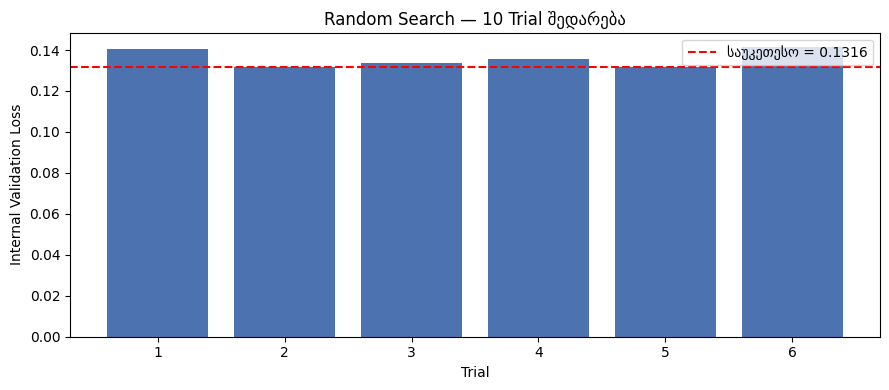

In [71]:
fig, ax = plt.subplots(figsize=(9, 4))
losses = [r[1] for r in search_results]
ax.bar(range(1, len(losses) + 1), losses, color='#4C72B0')
ax.axhline(best_val_loss, color='red', linestyle='--', label=f'საუკეთესო = {best_val_loss:.4f}')
ax.set_xlabel('Trial')
ax.set_ylabel('Internal Validation Loss')
ax.set_title('Random Search — 10 Trial შედარება')
ax.legend()
plt.tight_layout()
plt.show()

Ensemble member 1/3 — საბოლოო train_loss=0.10746
Ensemble member 2/3 — საბოლოო train_loss=0.10747
Ensemble member 3/3 — საბოლოო train_loss=0.10795


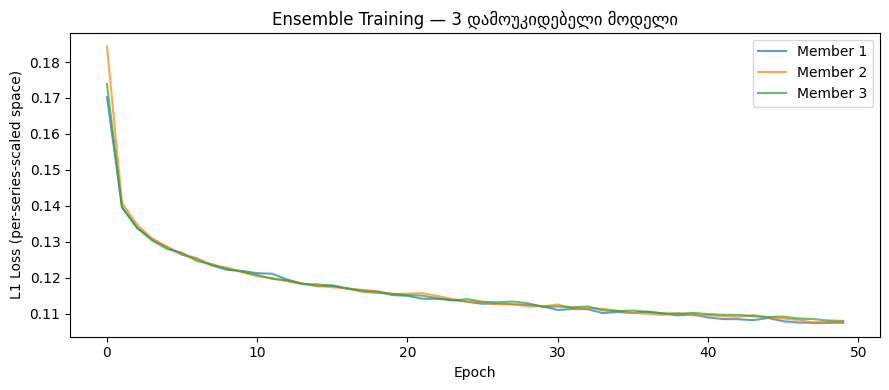

In [72]:
N_ENSEMBLE = 3
ENSEMBLE_EPOCHS = 50

ensemble_models = []
ensemble_train_losses = []

full_loader = DataLoader(global_dataset, batch_size=256, shuffle=True)

for member in range(N_ENSEMBLE):
    torch.manual_seed(200 + member)
    m = NBeatsNet(
        stack_types=['trend', 'seasonality', 'generic'], backcast_len=GLOBAL_BACKCAST,
        forecast_len=GLOBAL_FORECAST, hidden_dim=best_params['hidden_dim'],
        n_fc_layers=best_params['n_fc_layers'], n_blocks_per_stack=best_params['n_blocks_per_stack'],
        degree=best_params['degree'], num_harmonics=best_params['num_harmonics'],
    ).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=best_params['learning_rate'])
    crit = nn.L1Loss()

    member_losses = []
    for epoch in range(ENSEMBLE_EPOCHS):
        m.train()
        epoch_loss, epoch_n = 0.0, 0
        for xb, yb in full_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred = m(xb)
            loss = crit(pred, yb)
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * len(xb)
            epoch_n += len(xb)
        member_losses.append(epoch_loss / epoch_n)

    ensemble_models.append(m)
    ensemble_train_losses.append(member_losses)
    print(f"Ensemble member {member+1}/{N_ENSEMBLE} — საბოლოო train_loss={member_losses[-1]:.5f}")

fig, ax = plt.subplots(figsize=(9, 4))
for i, losses in enumerate(ensemble_train_losses):
    ax.plot(losses, alpha=0.7, label=f'Member {i+1}')
ax.set_xlabel('Epoch')
ax.set_ylabel('L1 Loss (per-series-scaled space)')
ax.set_title(f'Ensemble Training — {N_ENSEMBLE} დამოუკიდებელი მოდელი')
ax.legend()
plt.tight_layout()
plt.show()

In [73]:
for m in ensemble_models:
    m.eval()

predictions_by_key = {}

with torch.no_grad():
    for (s, d), scale in series_scales.items():
        series_vals = train_row_level[(train_row_level['Store'] == s) & (train_row_level['Dept'] == d)].sort_values('Date')['Weekly_Sales'].values
        if len(series_vals) < GLOBAL_BACKCAST:
            continue
        backcast_scaled = series_vals[-GLOBAL_BACKCAST:] / scale
        x = torch.tensor(backcast_scaled, dtype=torch.float32).unsqueeze(0).to(device)

        member_preds = [m(x).cpu().numpy().flatten() for m in ensemble_models]
        ensemble_pred_scaled = np.mean(member_preds, axis=0)
        predictions_by_key[(s, d)] = ensemble_pred_scaled * scale

print(f"Ensemble prediction გენერირებულია {len(predictions_by_key)} (Store, Dept) სერიისთვის")

Ensemble prediction გენერირებულია 2865 (Store, Dept) სერიისთვის


In [74]:
val_dates_sorted = sorted(val_series['Date'].unique())

rows_true, rows_pred, rows_holiday = [], [], []
covered, fallback = 0, 0
global_fallback_value = train_row_level['Weekly_Sales'].mean()

for _, row in val_row_level.iterrows():
    key = (row['Store'], row['Dept'])
    if key in predictions_by_key:
        try:
            week_idx = val_dates_sorted.index(row['Date'])
            pred_val = predictions_by_key[key][week_idx]
            covered += 1
        except (ValueError, IndexError):
            pred_val = global_fallback_value
            fallback += 1
    else:
        series_hist = train_row_level[(train_row_level['Store'] == row['Store']) & (train_row_level['Dept'] == row['Dept'])]['Weekly_Sales']
        pred_val = series_hist.mean() if len(series_hist) > 0 else global_fallback_value
        fallback += 1

    rows_true.append(row['Weekly_Sales'])
    rows_pred.append(max(pred_val, 0))
    rows_holiday.append(row['IsHoliday'])

print(f"დაფარულია ნამდვილი N-BEATS ensemble prediction-ით: {covered} row")
print(f"Fallback (naive საშუალო): {fallback} row")
print(f"დაფარვის %: {covered / (covered + fallback) * 100:.1f}%")

global_wmae_val = wmae(np.array(rows_true), np.array(rows_pred), np.array(rows_holiday))
print("Global Multi-Series Ensemble - namdvili row-level WMAE_val: " + format(global_wmae_val, ".1f"))
print("(shedarebistvis) calkeuli (search-gareshe) global model: 3866.4")
print("(shedarebistvis) Aggregate+Disaggregation midgoma: 4446.2")
print("(shedarebistvis) LightGBM: 2746.5, Prophet: 4872.0")

დაფარულია ნამდვილი N-BEATS ensemble prediction-ით: 42649 row
Fallback (naive საშუალო): 2127 row
დაფარვის %: 95.2%
Global Multi-Series Ensemble - namdvili row-level WMAE_val: 3732.6
(shedarebistvis) calkeuli (search-gareshe) global model: 3866.4
(shedarebistvis) Aggregate+Disaggregation midgoma: 4446.2
(shedarebistvis) LightGBM: 2746.5, Prophet: 4872.0


In [75]:
log_run(
    "NBEATS_GlobalMultiSeries_Ensemble",
    params={**best_params, 'n_series': len(series_scales), 'n_windows': len(global_dataset),
            'search_trials': N_SEARCH_TRIALS, 'ensemble_size': N_ENSEMBLE, 'ensemble_epochs': ENSEMBLE_EPOCHS,
            'stride': STRIDE, 'coverage_pct': covered / (covered + fallback) * 100},
    metrics={'wmae_val': global_wmae_val, 'internal_val_loss': best_val_loss},
    model=ensemble_models[0],
)

2026/07/12 09:36:06 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 09:36:15 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 09:36:15 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


NBEATS_GlobalMultiSeries_Ensemble -> {'wmae_val': np.float64(3732.639402569664), 'internal_val_loss': 0.13163723753080336}
🏃 View run NBEATS_GlobalMultiSeries_Ensemble at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/5/runs/22edbed99cd5446cb196432ced3f8b48
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/5


# საბოლოო მოდელის არჩევა

In [76]:
aggregate_runs = {
    'Baseline_Generic': wmae_val1,
    'PlusTrend': wmae_val2,
    'PlusSeasonality': wmae_val3,
    'ShortBackcast': wmae_val4,
    'WiderNetwork': wmae_val5,
    'LowerLR': wmae_val6,
    'MoreBlocks': wmae_val7,
    'WeightedLoss': wmae_val8,
}
for name, v in sorted(aggregate_runs.items(), key=lambda x: x[1]):
    print(f"{name}: {v:.1f}")

best_aggregate_name = min(aggregate_runs, key=aggregate_runs.get)
print("saukeTeso agregirebuli konfiguracia:", best_aggregate_name, "WMAE_val =", aggregate_runs[best_aggregate_name])
print("Global Multi-Series ensemble (row-level): " + format(global_wmae_val, ".1f"))
print("=> Global Multi-Series პირდაპირ შედარებადია disaggregated რიცხვთან და, სავარაუდოდ, ეს არის ჩვენი რეალურად საუკეთესო, ყველაზე მართებული N-BEATS მიდგომა.")

ShortBackcast: 6606764.9
WiderNetwork: 7320794.4
MoreBlocks: 7491033.3
PlusSeasonality: 7888976.5
PlusTrend: 7921389.2
LowerLR: 8066639.7
Baseline_Generic: 8078331.4
WeightedLoss: 8448999.7
saukeTeso agregirebuli konfiguracia: ShortBackcast WMAE_val = 6606764.931851851
Global Multi-Series ensemble (row-level): 3732.6
=> Global Multi-Series პირდაპირ შედარებადია disaggregated რიცხვთან და, სავარაუდოდ, ეს არის ჩვენი რეალურად საუკეთესო, ყველაზე მართებული N-BEATS მიდგომა.


# Disaggregation საუკეთესო aggregate მოდელისთვის

In [77]:
best_model_map = {
    'Baseline_Generic': model1, 'PlusTrend': model2, 'PlusSeasonality': model3,
    'ShortBackcast': model4, 'WiderNetwork': model5, 'LowerLR': model6,
    'MoreBlocks': model7, 'WeightedLoss': model8,
}
best_aggregate_model = best_model_map[best_aggregate_name]

if best_aggregate_name == 'ShortBackcast':
    best_pred_scaled = pred4_scaled
else:
    _, best_pred_scaled = evaluate_on_true_val(best_aggregate_model)

best_pred_original = scaler.inverse_transform(best_pred_scaled.reshape(-1, 1)).flatten()

store_dept_mean = train_row_level.groupby(['Store', 'Dept'])['Weekly_Sales'].mean()
share = (store_dept_mean / store_dept_mean.sum()).reset_index().rename(columns={'Weekly_Sales': 'share'})

forecast_by_date = pd.Series(best_pred_original, index=val_series['Date'].values)
merged = val_row_level.merge(share, on=['Store', 'Dept'], how='left')

missing_share_count = merged['share'].isna().sum()
print(f"Store/Dept წყვილი train-ისტორიის გარეშე (NaN share): {missing_share_count} / {len(merged)}")
merged['share'] = merged['share'].fillna(0)

merged['yhat_row'] = (merged['Date'].map(forecast_by_date) * merged['share']).clip(lower=0)

aggregate_disagg_wmae_val = wmae(merged['Weekly_Sales'], merged['yhat_row'], merged['IsHoliday'])
print(f"Aggregate+Disaggregation — row-level WMAE_val: {aggregate_disagg_wmae_val:.1f}")
print(f"Global Multi-Series — row-level WMAE_val:      {global_wmae_val:.1f}")

Store/Dept წყვილი train-ისტორიის გარეშე (NaN share): 171 / 44776
Aggregate+Disaggregation — row-level WMAE_val: 4437.1
Global Multi-Series — row-level WMAE_val:      3732.6


In [78]:
log_run(
    "NBEATS_Disaggregated_Comparable",
    params={'method': 'proportional_share_by_store_dept_mean', 'base_config': best_aggregate_name},
    metrics={'wmae_val_aggregate': aggregate_runs[best_aggregate_name], 'wmae_val_row_level': aggregate_disagg_wmae_val},
    model=None,
)

NBEATS_Disaggregated_Comparable -> {'wmae_val_aggregate': np.float64(6606764.931851851), 'wmae_val_row_level': np.float64(4437.067388218426)}
🏃 View run NBEATS_Disaggregated_Comparable at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/5/runs/c33be077f67e452eaab2905a2041ad86
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/5


# საბოლოო არჩევანი და რეგისტრაცია Model Registry ში

In [79]:
if global_wmae_val <= aggregate_disagg_wmae_val:
    final_approach = 'GlobalMultiSeries'
    final_model = ensemble_models[0]
    final_row_wmae = global_wmae_val
    final_params = {
        'approach': 'global_multi_series', 'stack_types': 'trend+seasonality+generic',
        'backcast_len': GLOBAL_BACKCAST, 'forecast_len': GLOBAL_FORECAST, 'n_series': len(series_scales),
    }
else:
    final_approach = 'Aggregate_' + best_aggregate_name
    final_model = best_aggregate_model
    final_row_wmae = aggregate_disagg_wmae_val
    final_params = {
        'approach': 'aggregate_disaggregation', 'selected_config': best_aggregate_name,
        'backcast_len': BACKCAST_SHORT if best_aggregate_name == 'ShortBackcast' else BACKCAST_LENGTH,
        'forecast_len': FORECAST_LENGTH,
    }

print("საბოლოოდ არჩეული მიდგომა:", final_approach, "| row-level WMAE_val =", final_row_wmae)

log_run(
    "NBEATS_Final",
    params=final_params,
    metrics={'wmae_val_row_level': final_row_wmae},
    model=final_model,
    registered_name="NBEATS_WalmartSales",
)

საბოლოოდ არჩეული მიდგომა: GlobalMultiSeries | row-level WMAE_val = 3732.639402569664


2026/07/12 09:36:47 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 09:36:53 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 09:36:53 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Successfully registered model 'NBEATS_WalmartSales'.
202

NBEATS_Final -> {'wmae_val_row_level': np.float64(3732.639402569664)}
🏃 View run NBEATS_Final at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/5/runs/92187e150f484e3d80cf32b49e59e630
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/5
